# Quantum Fourier Transform (QFT)

In this notebook, we will implement the Quantum Fourier Transform (QFT) circuit using Qiskit. The QFT is a fundamental quantum algorithm that plays a crucial role in many quantum algorithms, including Shor's algorithm for factoring integers.
We are going to follow the IBM Quantum Learning Guide [IBM Quantum Fourier Transform](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/qft).

## Importing Required Libraries

In [ ]:
from numpy import pi
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.visualization import plot_bloch_multivector

### Quantum Fourier Transform (QFT) Circuit Construction

The Quantum Fourier Transform (QFT) is the quantum analogue of the classical discrete Fourier transform. Instead of mapping classical data arrays, it maps quantum states from the computational basis to the phase (Fourier) basis. Within Shor's algorithm, this mathematical transformation is strictly necessary to extract the hidden period $r$ encoded in the quantum phases.

The analytical construction of the QFT circuit for an $n$-qubit register is implemented iteratively through three primary operations:

1. **Phase Initialization (Hadamard Gates):** The outer loop steps through the qubits in reverse order. For each qubit $i$, a Hadamard ($H$) gate is applied. This places the qubit into an equal superposition on the equatorial plane of the Bloch sphere, preparing it to accumulate precise phase shifts.

2. **Fractional Phase Kickback (Controlled Rotations):** The nested loop applies conditional phase rotations ($CP$ gates) controlled by the remaining qubits $j$. The rotation angle decays exponentially as the distance between the target and control qubits increases, strictly following the mathematical relation $\theta = \frac{\pi}{2^{i-j}}$. This cascading sequence elegantly distributes the fractional phase information across the entire quantum register.

3. **Endianness Correction (SWAP Gates):** Due to the asymmetric nature of the cascading controlled rotations, the theoretical output of the QFT emerges with its qubit order reversed. The final loop applies standard `SWAP` gates symmetrically across the register to mirror the physical layout back to standard Little-Endian or Big-Endian readout formats.

**Note on Qubit Ordering (Endianness):**

In standard quantum computing literature, the least significant qubit (LSB) is typically represented at the bottom of the circuit. For instance, to represent the number 3 (which is `0011` in binary) using 4 qubits, the state would be initialized as:

$$\begin{matrix}
|q_0\rangle = |0\rangle & \text{(MSB)} \\
|q_1\rangle = |0\rangle & \\
|q_2\rangle = |1\rangle & \\
|q_3\rangle = |1\rangle & \text{(LSB)}
\end{matrix}$$

However, frameworks like Qiskit use Little-Endian ordering, meaning the least significant qubit is always located at the top wire (index 0). Therefore, to represent the number 3 in Qiskit, the initialization must be inverted:

$$\begin{matrix}
|q_0\rangle = |1\rangle & \text{(LSB)} \\
|q_1\rangle = |1\rangle & \\
|q_2\rangle = |0\rangle & \\
|q_3\rangle = |0\rangle & \text{(MSB)}
\end{matrix}$$

In [ ]:
def qft(n_qubits: int) -> QuantumCircuit:
    """Generates the QFT circuit for n_qubits qubits.
    Args:
        n_qubits (int): Number of qubits.
    Returns:
        QuantumCircuit: The QFT circuit for n_qubits qubits.
    """
    qft_circ = QuantumCircuit(n_qubits)

    # Iterative application of Hadamard and Controlled Rotations
    for i in range(n_qubits - 1, -1, -1):
        qft_circ.h(i)  # apply Hadamard gate to qubit i
        for j in range(i - 1, -1, -1):
            angle = pi / (2 ** (i - j)) # The rotation angle is halved at each step
            qft_circ.cp(angle, j, i)
        qft_circ.barrier(range(n_qubits))  # for legibility

    for i in range(n_qubits // 2):  # Final inversion of the qubit order using SWAPs
        qft_circ.swap(i, n_qubits - i - 1)

    return qft_circ

Finally, this is the Quantum Fourier Transform circuit for 3 qubits:

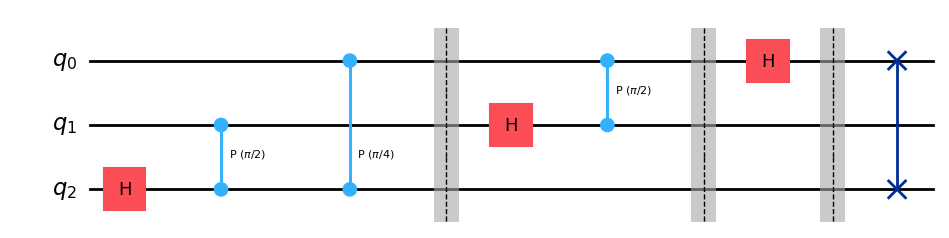

In [3]:
qft(3).draw("mpl")

### Visualization of the QFT Application

Let's observe how the number 3 (state $|11\rangle$) is mapped into the Fourier basis using 2 qubits.

In [4]:
n = 2
circ = QuantumCircuit(n)

# Initialize the state |11> (number 3 in decimal)
circ.x(0)
circ.x(1)

# Append the QFT to the circuit
circ.compose(qft(n), inplace=True)

To visualize the result, we will use the `Statevector` class from Qiskit's `quantum_info` module. Unlike hardware execution—which collapses the superposition into a single classical state upon measurement—the statevector simulator gives us the exact mathematical state of the qubits. This is an analytical tool strictly used to understand the phase transformations clearly; a real quantum computer will never output this vector directly.


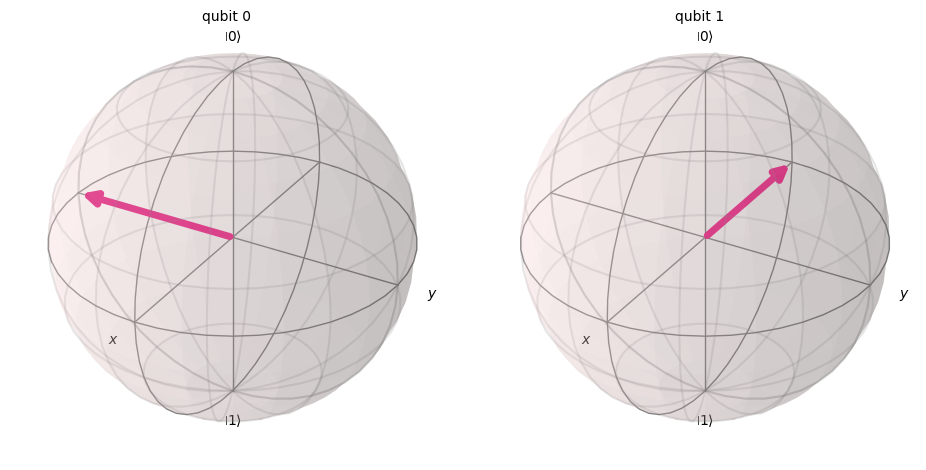

In [5]:
# Extract the analytical statevector
state = Statevector(circ)
display(plot_bloch_multivector(state))

As expected, the results perfectly reflect the theoretical QFT equations. In the Fourier basis, the phase acquired by the $k$-th qubit for an input integer $x$ is defined as $e^{2\pi i \frac{x}{2^{n-k}}}$. For $n=2$ and $x=3$:

* The most significant qubit ($q_1$, bottom) rotates by an angle of $2\pi \cdot \frac{3}{4} = \frac{3\pi}{2}$ radians, which is $270^\circ$ or $3/4$ of a full turn (pointing to the -Y axis).
* The least significant qubit ($q_0$, top) rotates by an angle of $2\pi \cdot \frac{3}{2} = 3\pi \equiv \pi$ radians, which is $180^\circ$ or $1/2$ of a full turn (pointing to the -X axis).

## Inverse Quantum Fourier Transform ($QFT^\dagger$)

The Inverse Transform ($QFT^\dagger$) is required to decode the frequency information back into the computational basis. It can be derived analytically by reversing the sequence of operations of the standard QFT and applying the conjugate transpose (inverse) of each gate. Therefore, we begin by applying the SWAP gates, followed by the controlled phase rotations in reverse order using negative angles.

*Note:* We will call the inverse QFT function IQFT or $QFT^\dagger$.

In [ ]:
def iqft(n_qubits: int) -> QuantumCircuit:
    """Generates the Inverse QFT (IQFT) circuit for n_qubits qubits analytically.
    Args:
        n_qubits (int): Number of qubits.
    Returns:
        QuantumCircuit: The IQFT circuit for n_qubits qubits.
    """
    circ = QuantumCircuit(n_qubits)

    # 1. Reverse the SWAP gates
    for i in range(n_qubits // 2):
        circ.swap(i, n_qubits - i - 1)

    circ.barrier(range(n_qubits))

    # 2. Reverse the Hadamard and Controlled Phase rotations
    for i in range(n_qubits):
        for j in range(i):
            # The angle is negated and gates are applied in reverse order
            angle = -pi / (2 ** (i - j))
            circ.cp(angle, j, i)
        circ.h(i)
        circ.barrier(range(n_qubits))

    return circ


There is the $QFT^\dagger$ circuit for 3 qubits:

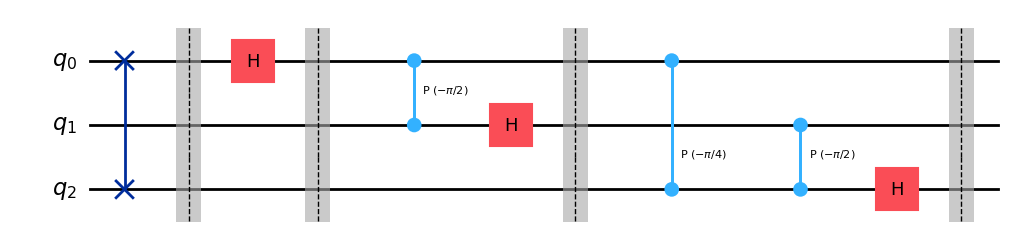

In [8]:
iqft(3).draw("mpl")

### Inverse QFT Corroboration

As we can see, the IQFT circuit is essentially the reverse of the QFT circuit, with the controlled phase rotations applied in the opposite order and with negative angles. This allows us to recover the original computational basis state from the Fourier basis representation.

Thanks to the modularity of Qiskit, it is not strictly necessary to build the inverse circuit gate by gate in practical applications. As we know every quantum gate has an inverse, so Qiskit provides the built-in `.inverse()` method to obtain the inverse of any circuit. This is particularly useful for the QFT, as it allows us to easily construct the IQFT by simply calling this method on the QFT circuit.

To prove the robustness of our analytical implementation, we can extract the unitary matrices (Operators) of both approaches and compare them mathematically.

In [ ]:
# Generate circuits using both approaches for 3 qubits
iqft_analytical = iqft(3)
iqft_method = qft(3).inverse()

# Compare their underlying unitary matrices
are_equivalent = Operator(iqft_analytical) == Operator(iqft_method)

print(f"Are both IQFT implementations mathematically equivalent? {are_equivalent}")


Are both IQFT implementations mathematically equivalent? True
